#### ACF and PACF Analysis

1.  ACF --------------->  Autocorrelation Function

    (a.)    The main role of ACF is to find out the correlations between the current values and the past values.

2.  PACF -------------->  Partial Autocorrelation Function.

    (a.)    The main role of PACF is to remove the intermediate correlations.

#### Problem Statements:------------

1.  The main aim of the problem statement is 

    (a.)    to understand the autocorrelation in the time series data.

    (b.)    to identify the AR(p) and MA(q) components.

    (c.)    to prepare the data for ARIMA modeling.

#### Step 1: Import all the necessary libraries

In [485]:
import  numpy               as  np
import  pandas              as  pd
import  matplotlib.pyplot   as  plt
import  seaborn             as  sns

from    statsmodels.tsa.stattools       import  acf,pacf,adfuller
from    statsmodels.graphics.tsaplots   import  plot_acf,plot_pacf

#### Step 2: Load the dataset

In [486]:
#### Load the dataset

df = pd.read_csv('AirPassengers.csv')

In [487]:
df

,date,value
0,1949-01-01,112
1,1949-02-01,118
2,1949-03-01,132
3,1949-04-01,129
4,1949-05-01,121
...,...,...
139,1960-08-01,606
140,1960-09-01,508
141,1960-10-01,461
142,1960-11-01,390


#### OBSERVATIONS:

1.  The above dataset represents the airline passengers data for the starting date of each month beginning from 1949 till 1960.

#### Step 3: Perform Data Exploration

In [488]:
#### get the first five rows of the dataset

df.head()

,date,value
0,1949-01-01,112
1,1949-02-01,118
2,1949-03-01,132
3,1949-04-01,129
4,1949-05-01,121


In [489]:
#### get the last five rows of the dataset

df.tail()

,date,value
139,1960-08-01,606
140,1960-09-01,508
141,1960-10-01,461
142,1960-11-01,390
143,1960-12-01,432


In [490]:
#### get the length of the dataset

print("Length of the dataset is:", len(df))

Length of the dataset is: 144


In [491]:
#### get the shape of the dataset

print("Shape of the dataset is:", df.shape)

Shape of the dataset is: (144, 2)


In [492]:
#### get the column used in the dataset

df.columns

Index(['date', 'value'], dtype='object')

In [493]:
#### get the information about the columns used in the dataset

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   date    144 non-null    object
 1   value   144 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 2.4+ KB


#### Step 4: Perform Data Cleaning and Feature Engineering

In [494]:
#### Convert the object type of date column to date

df['date']  =   pd.to_datetime(df['date'])

In [495]:
#### get the information about the columns used in the dataset

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    144 non-null    datetime64[ns]
 1   value   144 non-null    int64         
dtypes: datetime64[ns](1), int64(1)
memory usage: 2.4 KB


#### OBSERVATIONS:

1.  The date column has been converted from 'object' type to 'datetime' type.

In [496]:
#### To set the date column as an index

df.set_index('date',inplace=True)

In [497]:
df.head()

,value
date,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


#### OBSERVATIONS:

1.  The date column has been set as an index.

In [498]:
#### To check for the NULL records in the dataframe

df.isnull().sum()

value    0
dtype: int64

#### OBSERVATIONS:

1.  There are no NULL records in the dataset.

In [499]:
#### Rename the column name 'value' to 'Passengers'

df.rename(columns={'value':'Passengers'},inplace=True)

#### Step 5: Plot the time series data

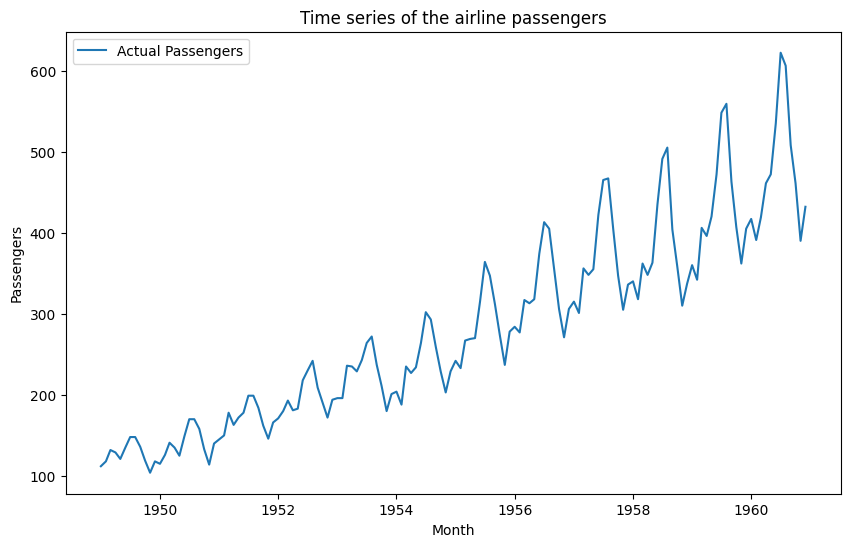

In [500]:
plt.figure(figsize=(10,6))

#### plot the original time series
plt.plot(df.index, df['Passengers'], label = 'Actual Passengers')

#### give the title of the graph
plt.title('Time series of the airline passengers')

#### give the x axis of the graph
plt.xlabel('Month')

#### give the y-axis of the graph
plt.ylabel('Passengers')

#### give the legend of the graph
plt.legend()

#### display the graph
plt.show()

#### OBSERVATIONS:

1.  The above graph represents the passengers data for the starting date of every month starting from 1944 till 1960.

2.  With the increase in years, the number of passengers also increases, so the trned also increases.

3.  As the trend continuously increases in the upward direction, so the time series is non stationary in nature.

#### Step 6: Check the Stationarity of the time series

In [501]:
from statsmodels.tsa.stattools  import  adfuller

#### perform the adfuller on the passengers data

res = adfuller(df['Passengers'])

#### Print the details of adfuller

print('Test Statistics is:', res[0])    ####### measures the stationarity strength

print('P Value is:', res[1])            ####### measures ehether the time series is stationary or not

print('Lag Value is:', res[2])          ####### determines the number of lag observations

print('Number of Observations is:', res[3])  ######### determines the number of total observations

print('Critical values are:')            ####### determines the critical values used

for key,value in res[4].items():
    print(key,":",value)

Test Statistics is: 0.8153688792060482
P Value is: 0.991880243437641
Lag Value is: 13
Number of Observations is: 130
Critical values are:
1% : -3.4816817173418295
5% : -2.8840418343195267
10% : -2.578770059171598


#### OBSERVATIONS:

1.  If p_value < 0.05 =============> the time series data is stationary else non-stationary.

2.  Here p_value = 0.99 which is greater than 0.05 , so the time series data is non-stationary.

#### Step 7: Perform First Order differencing on the passengers data

In [502]:
#### perform first order differencing on the passengers data

df_diff = df['Passengers'].diff()

In [503]:
#### Remove all the NULL records from the revised data

df_diff = df_diff.dropna()

In [504]:
df_diff

date
1949-02-01     6.0
1949-03-01    14.0
1949-04-01    -3.0
1949-05-01    -8.0
1949-06-01    14.0
              ... 
1960-08-01   -16.0
1960-09-01   -98.0
1960-10-01   -47.0
1960-11-01   -71.0
1960-12-01    42.0
Name: Passengers, Length: 143, dtype: float64

In [505]:
#### get the length of the dataset

print("Length of the dataset is:", len(df_diff))

Length of the dataset is: 143


In [506]:
#### get the shape of the dataset

print("Shape of the dataset is:", df_diff.shape)

Shape of the dataset is: (143,)


#### Step 8: Perform ADF test on the revise dataset

In [507]:
res = adfuller(df_diff)

In [508]:
#### Print the details of adfuller

print('Test Statistics is:', res[0])    ####### measures the stationarity strength

print('P Value is:', res[1])            ####### measures ehether the time series is stationary or not

print('Lag Value is:', res[2])          ####### determines the number of lag observations

print('Number of Observations is:', res[3])  ######### determines the number of total observations

print('Critical values are:')            ####### determines the critical values used

for key,value in res[4].items():
    print(key,":",value)

Test Statistics is: -2.8292668241699994
P Value is: 0.0542132902838255
Lag Value is: 12
Number of Observations is: 130
Critical values are:
1% : -3.4816817173418295
5% : -2.8840418343195267
10% : -2.578770059171598


#### OBSERVATIONS:

1.  If p_value <= 0.05 ==================>  time series is stationary else non-stationary.

2.  Here p_value = 0.05, so is concluded that the time series is stationary.

==========================================================================================


1.  ACF =================>

    (a.)    It stands for Auto Correlated Function.

    (b.)    It is used to find out the correlation of a current value with the past values.

    (c.)    It is used to identify the MA(q) value (Moving Average).

2. PACF ==================>

    (a.)    It stands for Partial Autocorrelation Function.

    (b.)    It is used to remove the indirect correlations.

    (c.)    It is used to identify AR(p) value (Auto Regression).




#### Step 8: Perform ACF Plots

<Figure size 1000x600 with 0 Axes>

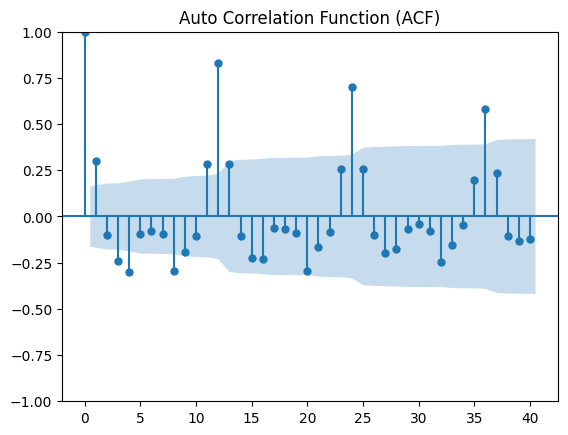

In [509]:
plt.figure(figsize=(10,6))

#### plot and visualize the ACF plots
plot_acf(df_diff, lags=40)

#### get the title of the graph
plt.title('Auto Correlation Function (ACF)')

#### display the graph
plt.show()

#### OBSERVATIONS:

1.  plot_acf() =============>

    This function is used to show the correlation of the current value with the past 40 values.

    It is used to identify MA(q) value

#### Step 9: Perform PACF Plots

<Figure size 1000x600 with 0 Axes>

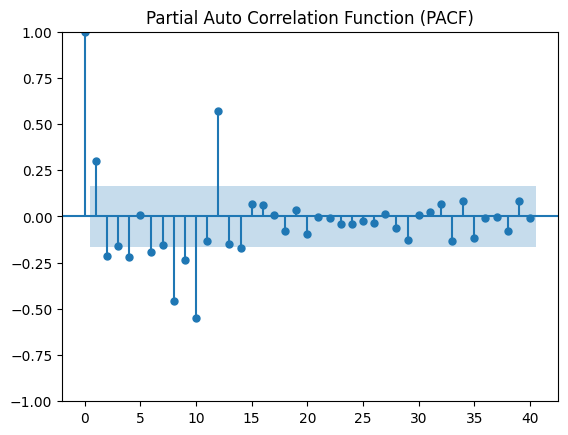

In [510]:
plt.figure(figsize=(10,6))

#### perform the plotting of pacf plots
plot_pacf(df_diff, lags=40, method='ywm')


#### get the title of the graph
plt.title('Partial Auto Correlation Function (PACF)')

#### display the graph
plt.show()

#### OBSERVATIONS:

1.  plot_pacf ====================>

    This function is used to remove the indirect correlations.

    It is used to find out the AR(p) values.



#### CONCLUSIONS:

1.  After obtaining the p and q values, it is used to prepare the data for ARIMA modeling.